In [ ]:
!pip install ultralytics deepface opencv-python-headless tf-keras --quiet


In [ ]:
from google.colab import files

print('Upload an image with one or more faces:')
uploaded   = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]


Upload an image with one or more faces:


Saving men_women.jpeg to men_women (6).jpeg


Code for predicting only gender and displaying confidence as label

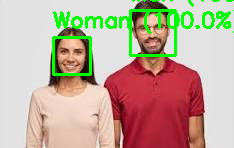

Saved as gender_output.jpg


In [ ]:
import cv2
from deepface import DeepFace #DeepFace provides facial analysis features such as gender, age, emotion, race, and face recognition.
from google.colab.patches import cv2_imshow

# Read image
image = cv2.imread(IMAGE_PATH) #image returned as numpy array

if image is None:
    raise FileNotFoundError(f"Could not read image: {IMAGE_PATH}")

# Analyze only gender
results = DeepFace.analyze(
    image,
    actions=['gender'],
    enforce_detection=False #normally face is needed for detection making it False helps even when face is uncertain
)

# If only one face is detected, convert to list
if not isinstance(results, list):
    results = [results]

# Draw bounding boxes and labels
for face in results:
    x = face['region']['x']
    y = face['region']['y']
    w = face['region']['w']
    h = face['region']['h']

    gender = face['dominant_gender']
    confidence = face['gender'][gender]

    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    label = f"{gender} ({confidence:.1f}%)" #display label on image using putText()
    cv2.putText(
        image,
        label,
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

# Save output image
cv2.imwrite("gender_output.jpg", image)

# Display image in Colab
cv2_imshow(image)

print("Saved as gender_output.jpg")

Predicting gender and age together

In [ ]:
import cv2
from deepface import DeepFace
from google.colab.patches import cv2_imshow

# Read image
image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(f"Could not read image: {IMAGE_PATH}")


Analyzing gender , age,emotion,race

In [ ]:
results = DeepFace.analyze(
    image,
    actions=['gender', 'age','emotion','race'],
    enforce_detection=False
)

if not isinstance(results, list):
    results = [results]

for face in results:
    x = face['region']['x']
    y = face['region']['y']
    w = face['region']['w']
    h = face['region']['h']

    gender = face['dominant_gender']
    confidence = face['gender'][gender]

    age = face['age']
    emotion = face['dominant_emotion']
    race=face['dominant_race']

    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)



Action: race:  50%|█████     | 2/4 [00:02<00:02,  1.06s/it]   

26-06-16 17:46:03 - 🔗 race_model_single_batch.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5 to /root/.deepface/weights/race_model_single_batch.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5
To: /root/.deepface/weights/race_model_single_batch.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  2%|▏         | 11.0M/537M [00:00<00:04, 107MB/s]
  5%|▌         | 28.3M/537M [00:00<00:03, 145MB/s]
  8%|▊         | 43.0M/537M [00:00<00:03, 144MB/s]
 12%|█▏        | 63.4M/537M [00:00<00:02, 163MB/s]
 15%|█▍        | 80.2M/537M [00:00<00:03, 151MB/s]
 18%|█▊        | 95.4M/537M [00:00<00:03, 133MB/s]
 21%|██▏       | 114M/537M [00:00<00:02, 148MB/s] 
 24%|██▍       | 130M/537M [00:01<00:03, 108MB/s]
 27%|██▋       | 143M/537M [00:01<00:04, 92.2MB/s]
 29%|██▊       | 154M/537M [00:01<00:04, 91.0MB/s]
 32%|███▏      | 169M/537M [00:01<00:03, 105MB/s] 
 34%|███▍      | 181M/537M [00:01<00:04, 75.7MB/s]
 36%|███▌      | 191M/537M [00:01<00:04, 76.2MB/s]
 39%|███▉      | 210M/537M [00:01<00:03, 98.6MB/s]
 41%|████▏     | 222M/537M [00:02<00:03, 97.7MB/s]
 47%|████▋     | 250M/

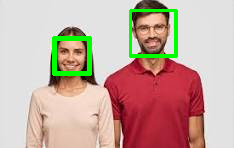

In [ ]:
cv2_imshow(image)

In [ ]:
for i, face in enumerate(results, start=1):
    print(
        f"Face {i}: "
        f"Gender={face['dominant_gender']}, "
        f"Confidence={face['gender'][face['dominant_gender']]:.2f}%, "
        f"Age={face['age']}"
        f"Emotion = {face['dominant_emotion']}"
        f"Race = {face['dominant_race']}"
    )

Face 1: Gender=Woman, Confidence=99.92%, Age=24Emotion = happyRace = white
Face 2: Gender=Man, Confidence=100.00%, Age=39Emotion = neutralRace = middle eastern
